# Compact
Load Compact CSV files and create a DataFrame named `df`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Compact"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()

Loaded 2045 rows from 214 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Compact


,Date,Title,Inhalt,URL,source,source_file
0,2025-06-11,COMPACT gegen Regierung: So war der 2. Tag!,Der zweite und letzte Verhandlungstag im COMPA...,https://www.compact-online.de/compact-gegen-re...,Compact,Compact_2025-06-11_raw.csv
1,2025-06-11,COMPACT-Verbot 2024: Der Film,Als Nancy Faeser eskalierte. Die denkwürdigste...,https://www.compact-online.de/compact-verbot-2...,Compact,Compact_2025-06-11_raw.csv
2,2025-06-11,Drogen und Rituale: Mysteriöse Inka-Stätte ent...,Ein neuer Fund in den peruanischen Anden eröff...,https://www.compact-online.de/drogen-und-ritua...,Compact,Compact_2025-06-11_raw.csv
3,2025-06-11,Trumps Einsatz in Los Angeles: Ein Medientrauma,Das Durchgreifen des US-Präsidenten gegen das ...,https://www.compact-online.de/trumps-einsatz-i...,Compact,Compact_2025-06-11_raw.csv
4,2025-06-11,Verrat an BismarckCOMPACT+,Essay von Rolf Hochhut. Deutschland hat seinen...,https://www.compact-online.de/verrat-an-bismarck/,Compact,Compact_2025-06-11_raw.csv


In [2]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Title,0,0.0
Inhalt,0,0.0
URL,0,0.0
source,0,0.0
source_file,0,0.0


In [3]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"
dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= start) & (dates <= end)

df_aug2025_jan2026 = df_clean.loc[mask].copy()
df_aug2025_jan2026["Date"] = pd.to_datetime(df_aug2025_jan2026["Date"])
df_clean = df_aug2025_jan2026.copy()

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 1614


,Date,Title,Inhalt,URL,source,source_file
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...,Compact,Compact_2025-08-01_raw.csv
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...,Compact,Compact_2025-08-01_raw.csv
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...,Compact,Compact_2025-08-01_raw.csv
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...,Compact,Compact_2025-08-01_raw.csv
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...,Compact,Compact_2025-08-01_raw.csv


In [4]:
# keep only the requested columns
_keep = ["Date", "Title", "Inhalt", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [5]:
from IPython.display import display
display(df_clean.head(3))

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...


Removal of "Mehr zum Thema"

In [6]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Inhalt"] = df_clean["Inhalt"].apply(remove_mehr_zum_thema)

In [7]:
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial...",https://www.compact-online.de/blond-linker-has...
345,2025-08-01,Die Macht der Israel-Lobby in den USA,Die beinharte Unterstützung Donald Trumps für ...,https://www.compact-online.de/die-macht-der-is...
346,2025-08-01,Ein Polizist aus dem Volk,Karsten Hilse im Porträt. Ein Menetekel: Am Ta...,https://www.compact-online.de/ein-polizist-aus...
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gers...,Die Bundesregierung möchte die politischer Som...,https://www.compact-online.de/spd-politiker-fo...
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: T...",https://www.compact-online.de/die-grosse-vertu...


In [8]:
!pip install seaborn

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Inhalt"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 1,614


In [10]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    1614.0
mean      495.9
std       481.7
min        23.0
10%        70.0
25%       118.0
50%       419.0
75%       670.2
90%      1118.2
95%      1479.7
99%      2201.0
max      4324.0
Name: article_length_words, dtype: float64

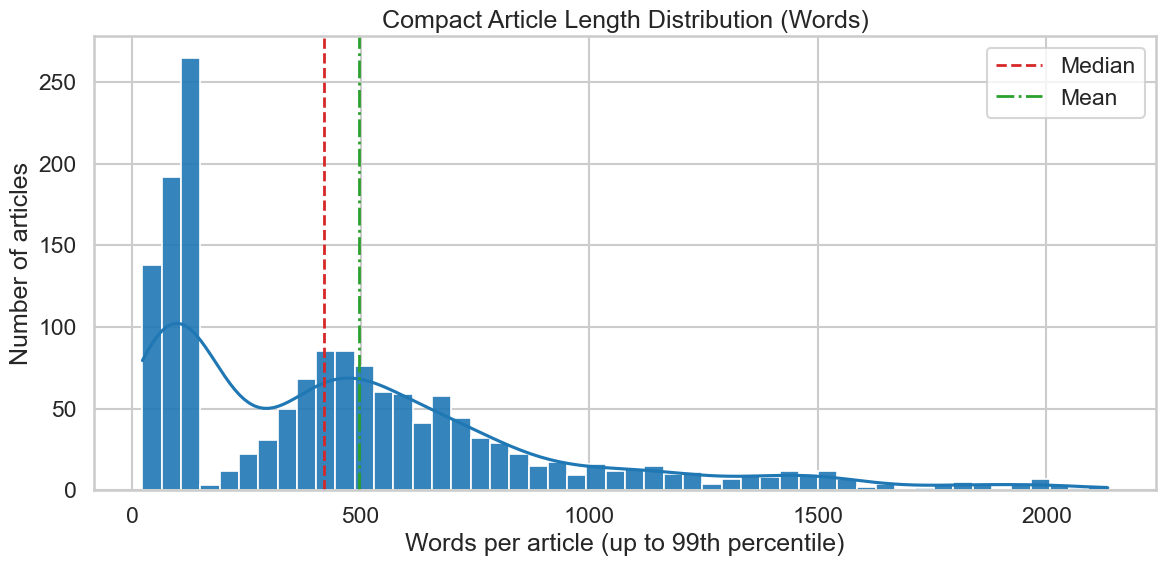

In [11]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Compact Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Inspect 20 shortest articles by word count
df_inspect = eda_df if "eda_df" in globals() else df_clean.copy()

if "article_length_words" not in df_inspect.columns:
    df_inspect["article_length_words"] = df_inspect["Inhalt"].astype("string").str.split().str.len()

# ensure source column exists (most data is from SOURCE_NAME == "Compact")
if "source" not in df_inspect.columns:
    df_inspect["source"] = SOURCE_NAME if "SOURCE_NAME" in globals() else "Compact"

# build result (Title, text, source, word_count) sorted ascending
shortest = (
    df_inspect.sort_values("article_length_words", ascending=True)
    .loc[:, ["Title", "Inhalt", "source", "article_length_words"]]
    .head(20)
    .rename(columns={"Inhalt": "text", "article_length_words": "word_count"})
)

# allow longer text columns to be displayed
pd.options.display.max_colwidth = 1000

display(shortest)

,Title,text,source,word_count
632,Macron am Boden: Live beim Aufstand!,Frankreich im Ausnahmezustand – COMPACT ist live vor Ort dabei!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,23
594,Albaner (18) sticht auf Lehrerin ein! NOT-OP!,Amoklauf in Essener Schule. SEK muss schießen. Dr. Stephanie Elsässer klärt auf!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,25
646,MOSSAD und 9/11,Heute vor 24 Jahren: Israelische Geheimdienstler wurden nach den Anschlägen des 11. September 2001 vom FBI festgenommen und zwei Monate eingesperrt. Waren sie in das Terrorkomplott verwickelt?,Compact,27
464,„Remigration!“: Söder-Interview wird abgebrochen!,Aufregung am Bundestag! Das Sommer-Interview der ARD mit CSU-Chef Söder muss abgebrochen werden.\n\nWir sind vor Ort!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,30
1187,Halle (Saale): Antifa brüllt gegen Buchmesse,"Wirbel um die «Seitenwechsel»-Buchmesse in Halle (Saale).\n\nSehen Sie hier brüllende Antifas, spannende Interviews und Impressionen von unserem Messestand!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,32
1901,Vor Ort: Orban geht gegen Hammerbande vor!,"In Budapest strebt der Prozess gegen Hammerbanden-„Maja“ seinem Höhepunkt entgegen. Unser Korrespondent Sebastian Schmidtke ist dabei und dokumentiert, wie deutsche Politiker vor Ort Stimmung machen.\n\nDie Reportage sehen Sie in dem Video oben.",Compact,33
1388,AfD-Jugend: COMPACT beim Kampf um Gießen!,"Ausnahmezustand in Gießen: Tausende Antifa wollen den Gründungskongress der AfD-Jugend stürmen! Blockaden, Wasserwerfer, Angriffe auf Polizisten und Teilnehmer. COMPACT mittendrin!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,33
1575,Gefahr Migration: Ex-Islamist packt aus!,Irfan Peci war Propaganda-Chef der deutschen al-Qaida! Inzwischen hat er zum christlichen Glauben gefunden und warnt vor den schrecklichen Folgen der Massenmigration. Was steht Deutschland bevor?\n\nUnsere heutige Shop-Empfehlung: „COMPACT-Spezial 45: Mädchen. Messer. Morde“,Compact,34
1656,Rückblick: Unsere größten TV-Highlights!,Nur noch wenige Stunden… – 2025 war ein spektakuläres Jahr mit vielen Höhen und Tiefen. In unserem COMPACT-Rückblick sehen Sie die wichtigsten Ereignisse in einer kurzweiligen Zusammenfassung. Wir wünschen einen frohen Jahreswechsel und ein gesundes Neues!,Compact,36
1692,Spreewald: Wird SIE die erste AfD-Landrätin?,Widerstand im Gurkenland: Der Kreis Oberspreewald-Lausitz gilt als AfD-Hochburg. In wenigen Tagen wird hier ein neuer Landrat gewählt. Die blaue Kandidatin hat gute Chancen. Paul Klemm hat sie mit der Kamera begleitet.\n\nUnsere heutige Produktempfehlung: Silbermedaille Höcke-Taler,Compact,37


--> This indicates two types of documents in the corpus: News briefs / ticker posts and Normal articles

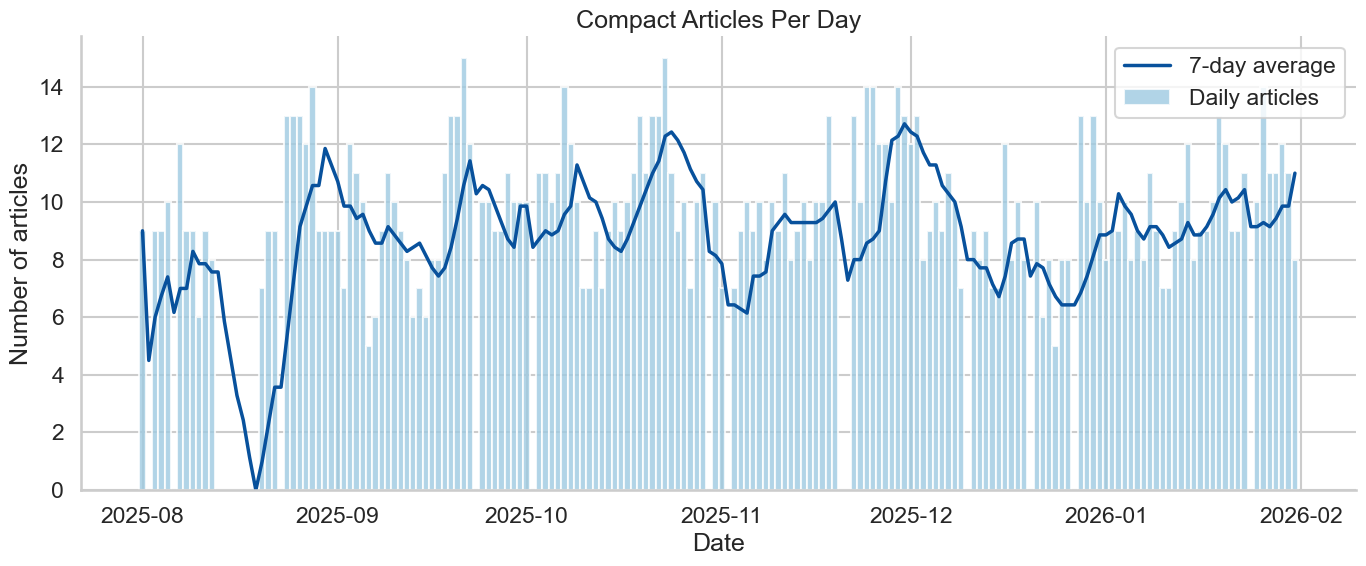

In [13]:
daily_counts = (
    eda_df.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("Compact Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## BERTopic

In [14]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

In [15]:
from bertopic_config import BERTopicConfig, title_config
from bertopic_pipeline import run_bertopic_pipeline


In [16]:
df_clean[["Inhalt", "Title", "URL"]].head()


,Inhalt,Title,URL
344,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Blond! Linker Hass gegen Jeans-Model,https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",Die Macht der Israel-Lobby in den USA,https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",Ein Polizist aus dem Volk,https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",SPD-Politiker fordert Rückzug von Brosius-Gersdorf,https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nicht. Trumps Kehrtwende wirft Fragen auf – und bringt die Gerüchteküche zum Brodeln. 

In [17]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "00_Initial EDA" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("Compact")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical Compact subset from df_combined: {len(df_clean):,} rows")


Loaded canonical Compact subset from df_combined: 1,486 rows


In [18]:
# 1) BERTopic on Compact documents with outlet-specific cleanup
# Compact article bodies contain recurring shop / self-promo copy, but a setup that is
# too permissive also over-splits this medium-sized corpus into microtopics. Use title+text
# as the main representation and a more moderate clustering profile.
compact_topic_df = df_clean.copy()
compact_topic_df["topic_text"] = (
    compact_topic_df["Title"].fillna("").astype(str).str.strip()
    + ". "
    + compact_topic_df["Text"].fillna("").astype(str).str.strip()
).str.replace(r"^\.\s*", "", regex=True).str.strip()

compact_extra_boilerplate_patterns = (
    r"(?is)hier\\s+mehr\\s+erfahren\\.?",
    r"(?is)hier\\s+bestellen\\.?",
    r"(?is)jetzt\\s+(?:hier\\s+)?bestellen\\.?",
    r"(?is)unbedingt\\s+einschalten\\.?",
    r"(?is)abonnieren\\s+sie\\s+gleich\\s+unseren\\s+youtube-kanal.*?(?:\\.|\\Z)",
    r"(?is)aktivieren\\s+die\\s+glocke.*?(?:\\.|\\Z)",
    r"(?is)um\\s+keine\\s+sendung\\s+mehr\\s+zu\\s+verpassen\\.?",
    r"(?is)compact-tv[^\\n\\.]*[\\.]?",
    r"(?is)brennpunkt[^\\n\\.]*[\\.]?",
    r"(?is)halten\\s+sie\\s+sich\\s+lieber\\s+an\\s+die\\s+compact-biografie[^\\n\\.]*[\\.]?",
    r"(?is)garantiert\\s+ohne\\s+hass\\s+und\\s+hetze\\.?",
    r"(?is)in\\s+der\\s+(?:aktuellen\\s+)?compact-(?:ausgabe|spezial|geschichte)[^\\n\\.]*[\\.]?",
    r"(?is)unsere\\s+(?:sonderausgabe|ausgabe|spezial-ausgabe|spezial)[^\\n\\.]*[\\.]?",
    r"(?is)unser\\s+(?:rabatt-paket|rabattpaket|argumenten-arsenal|sonderheft)[^\\n\\.]*[\\.]?",
)

compact_extra_stopwords = (
    "compact",
    "tv",
    "youtube",
    "kanal",
    "glocke",
    "ausgabe",
    "sonderausgabe",
    "sonderheft",
    "spezial",
    "titelthema",
    "rabattpaket",
    "rabatt",
    "paket",
    "bestellen",
    "erfahren",
    "medaille",
    "button",
    "shop",
    "magazin",
    "heft",
    "brennpunkt",
    "biografie",
)

config_full_text = BERTopicConfig(
    min_df=2,
    max_df=0.85,
    umap_n_neighbors=18,
    umap_min_dist=0.05,
    hdbscan_min_cluster_size=10,
    hdbscan_min_samples=3,
    hdbscan_cluster_selection_method="eom",
    nr_topics=None,
    extra_stopwords=compact_extra_stopwords,
    boilerplate_patterns=BERTopicConfig().boilerplate_patterns + compact_extra_boilerplate_patterns,
)

result_full_text = run_bertopic_pipeline(
    df=compact_topic_df,
    text_col="topic_text",
    config=config_full_text,
    id_col="row_id",
    source_name="Compact",
)

# 2) BERTopic on titles only
config_title = title_config(
    min_df=1,
    max_df=0.9,
    umap_n_neighbors=14,
    umap_min_dist=0.05,
    hdbscan_min_cluster_size=10,
    hdbscan_min_samples=3,
    extra_stopwords=compact_extra_stopwords,
)

result_title = run_bertopic_pipeline(
    df=compact_topic_df,
    text_col="Title",
    config=config_title,
    id_col="row_id",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 05:36:36,006 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

2026-03-31 05:36:55,312 - BERTopic - Embedding - Completed ✓
2026-03-31 05:36:55,316 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 05:37:20,304 - BERTopic - Dimensionality - Completed ✓
2026-03-31 05:37:20,320 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 05:37:20,495 - BERTopic - Cluster - Completed ✓
2026-03-31 05:37:20,539 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 05:37:22,155 - BERTopic - Representation - Completed ✓


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 05:37:34,095 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

2026-03-31 05:37:39,596 - BERTopic - Embedding - Completed ✓
2026-03-31 05:37:39,603 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 05:37:53,576 - BERTopic - Dimensionality - Completed ✓
2026-03-31 05:37:53,581 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 05:37:53,677 - BERTopic - Cluster - Completed ✓
2026-03-31 05:37:53,685 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 05:37:53,848 - BERTopic - Representation - Completed ✓


In [19]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,0,1402,0_spd_mann_seiten_ihrem,"[spd, mann, seiten, ihrem, bürger, opfer, grünen, gewalt, corona, gegen russland, merkel, stimmen, bsw, treffen, junge, mainstream, stadt, linken, offen, sachsen, morde, wehrpflicht, 12, bundestag, behörden, szene, berliner, rechts, aller, ort]","[Mega-Auftritt in der ausverkauften Kölner Lanxness-Arena: 16.000 Fans feiern die Rückkehr des Soul-Sängers, der während der Corona-Zeit in Ungnade fiel. Dem Mainstream ist das nicht geheuer, auch wenn die musikalischen Qualitäten des Mannheimers gewürdigt werden. Halten Sie sich lieber an die COMPACT-Biografie „Naidoo: Sein Leben, seine Lieder, seine Wut“. Garantiert ohne Hass und Hetze. Hier bestellen. Das Naidoo-Comeback ist auch Thema unseres heutigen Brennpunkts auf COMPACT-TV um 20 Uhr. Schalten Sie ein! Am besten abonnieren Sie gleich unseren Youtube-Kanal und aktivieren die Glocke, um keine Sendung mehr zu verpassen. Wer Xavier Naidoo schon abgeschrieben hatte, wurde gestern eines Besseren belehrt: Der einst von der Popwelt gefeierte Soul-Sänger ist mit einem wahren Paukenschlag zurück auf die Bühne gekehrt. 16.000 Fans feierten sein Comeback in der ausverkauften Lanxness-Arena in Köln – und der Mainstream ist sich nicht sicher: Soll man den während der Corona-Zeit „verlore..."
1,1,55,1_silbermedaillen_silberpreis_edelmetall_unze,"[silbermedaillen, silberpreis, edelmetall, unze, anleger, katharina, preis für, reserve, stieg, inflation, papierwährungen, federal reserve, federal, währungen, 20 januar, anstieg, zinsen, unzen, treibt, notenbank, freitag, bundesbank, physischem, putin höcke, goldreserven, feinunze, us notenbank, knapp, putin druschba, flüchten]","[Bis zum 20. Januar 2026 verkaufen wir unsere Silbermedaillen noch zum alten Preis. Danach müssen wir unsere Preise der Kursexplosion des Edelmetalls von fast 100 Prozent seit November anpassen. Deswegen: Jetzt bestellen. Der Silberpreis spielt verrückt. Allein ab dem 10. Januar ist der Preis für die Unze um über zehn Euro angestiegen, das sind knapp 15 Prozent. Seit Anfang November 2025 beträgt der Anstieg pro Unze fast 100 Prozent: Am 4. November lag er bei 40,99 Euro, am heutigen 18. Januar liegt er bei fast 78 Euro. Silber: Ein sicherer Hafen in Krisenzeiten. Foto: CodedeatH33 | Shutterstock.com COMPACT hat den Preis für unsere Silbermedaillen trotz der Kursexplosion seit November stabil gehalten. Das ist jetzt nicht mehr möglich, da sich die Entwicklungen überschlagen. Um es vorzurechnen: Seit November stieg die Unze um fast 40 Euro. Unsere Silbermedaillen haben eine halbe Unze, die wurde allein vom Rohmaterial her also um knapp 20 Euro teurer. Wir werden nicht den vollen Betr..."
2,2,29,2_cia_venezolanischen_maduros_drogen,"[cia, venezolanischen, maduros, drogen, venezolanische, daniele, chavez, operation, intervention, imperium, imperium usa, operationen, militärische, skrupellose, usa skrupellose, nicolás maduro, nicolás, küste venezuelas, skrupellose weltmacht, amerikanischer, weltmacht, 10 2025, heft, kokain, daniele gansers, gansers, karibik, gansers imperium, hintergründe, venezuela attackieren]","[Es brodelt in der Karibik. Während die Welt noch gebannt auf die Lage im Nahen Osten schaut, spitzt sich die Krise in Südamerika immer weiter zu. Die USA nehmen Venezuela ins Visier. In den vergangenen Tagen haben sich beunruhigende Hinweise verdichtet: Die US-Regierung plant geheimdienstliche Einsätze und rückt militärisch zunehmend vor – mit klarer Drohkulisse gegenüber Venezuela. Alle Hintegründe zum Konflikt finden Sie im Artikel „Sturmfront über Caracas: Warum die USA Venezuela attackieren“ im aktuellen COMPACT-Heft 10/2025. Hier mehr erfahren. _ von Karl Brüning So hat Präsident Trump offiziell bestätigt, dass er verdeckte CIA-Operationen in Venezuela genehmigt hat. Diese Einsätze sollen über reine Aufklärung hinausgehen und dem Sturz der Maduro-Regierung dienen. Ebenfalls wurden B-52-Bomber über karibischen Gewässern in der 

In [20]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,row_id,source,Date,Title,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,0,566,Compact,566,Compact,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie! Dr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.",0,0_spd_mann_seiten_ihrem,"[spd, mann, seiten, ihrem, bürger, opfer, grünen, gewalt, corona, gegen russland, merkel, stimmen, bsw, treffen, junge, mainstream, stadt, linken, offen, sachsen, morde, wehrpflicht, 12, bundestag, behörden, szene, berliner, rechts, aller, ort]","[Mega-Auftritt in der ausverkauften Kölner Lanxness-Arena: 16.000 Fans feiern die Rückkehr des Soul-Sängers, der während der Corona-Zeit in Ungnade fiel. Dem Mainstream ist das nicht geheuer, auch wenn die musikalischen Qualitäten des Mannheimers gewürdigt werden. Halten Sie sich lieber an die COMPACT-Biografie „Naidoo: Sein Leben, seine Lieder, seine Wut“. Garantiert ohne Hass und Hetze. Hier bestellen. Das Naidoo-Comeback ist auch Thema unseres heutigen Brennpunkts auf COMPACT-TV um 20 Uhr. Schalten Sie ein! Am besten abonnieren Sie gleich unseren Youtube-Kanal und aktivieren die Glocke, um keine Sendung mehr zu verpassen. Wer Xavier Naidoo schon abgeschrieben hatte, wurde gestern eines Besseren belehrt: Der einst von der Popwelt gefeierte Soul-Sänger ist mit einem wahren Paukenschlag zurück auf die Bühne gekehrt. 16.000 Fans feierten sein Comeback in der ausverkauften Lanxness-Arena in Köln – und der Mainstream ist sich nicht sicher: Soll man den während der Corona-Zeit „verlore...",spd - mann - seiten - ihrem - bürger - opfer - grünen - gewalt - corona - gegen russland - merkel - stimmen - bsw - treffen - junge - mainstream - stadt - linken - offen - sachsen - morde - wehrpflicht - 12 - bundestag - behörden - szene - berliner - rechts - aller - ort,1.0,False
1,1,567,Compact,567,Compact,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen. Diese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen. Das Buch von Mearsheimer/Wal...",0,0_spd_mann_seiten_ihrem,"[spd, mann, seiten, ihrem, bürger, opfer, grünen, gewalt, corona, gegen russland, merkel, stimmen, bsw, treffen, junge, mainstream, stadt, linken, offen, sachsen, morde, wehrpflicht, 12, bundestag, behörden, szene, berliner, rechts, aller, ort]","[Mega-Auftritt in der ausverkauften Kölner Lanxness-Arena: 16.000 Fans feiern die Rückkehr des Soul-Sängers, der während der Corona-Zeit in Ungnade fiel. Dem Mainstream ist das nicht geheuer, auch wenn die musikalischen Qualitäten des Mannheimers gewürdigt werden. Halten Sie sich lieber an die COMPACT-Biografie „Naidoo: Sein Leben, seine Lieder, seine Wut“. Garantiert ohne Hass und Hetze. Hier bestellen. Das Naidoo-Comeback ist auch Thema unseres heutigen Brennpunkts auf COMPACT-TV um 20 Uhr. Schalten Sie ein! Am 

In [21]:
compact_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

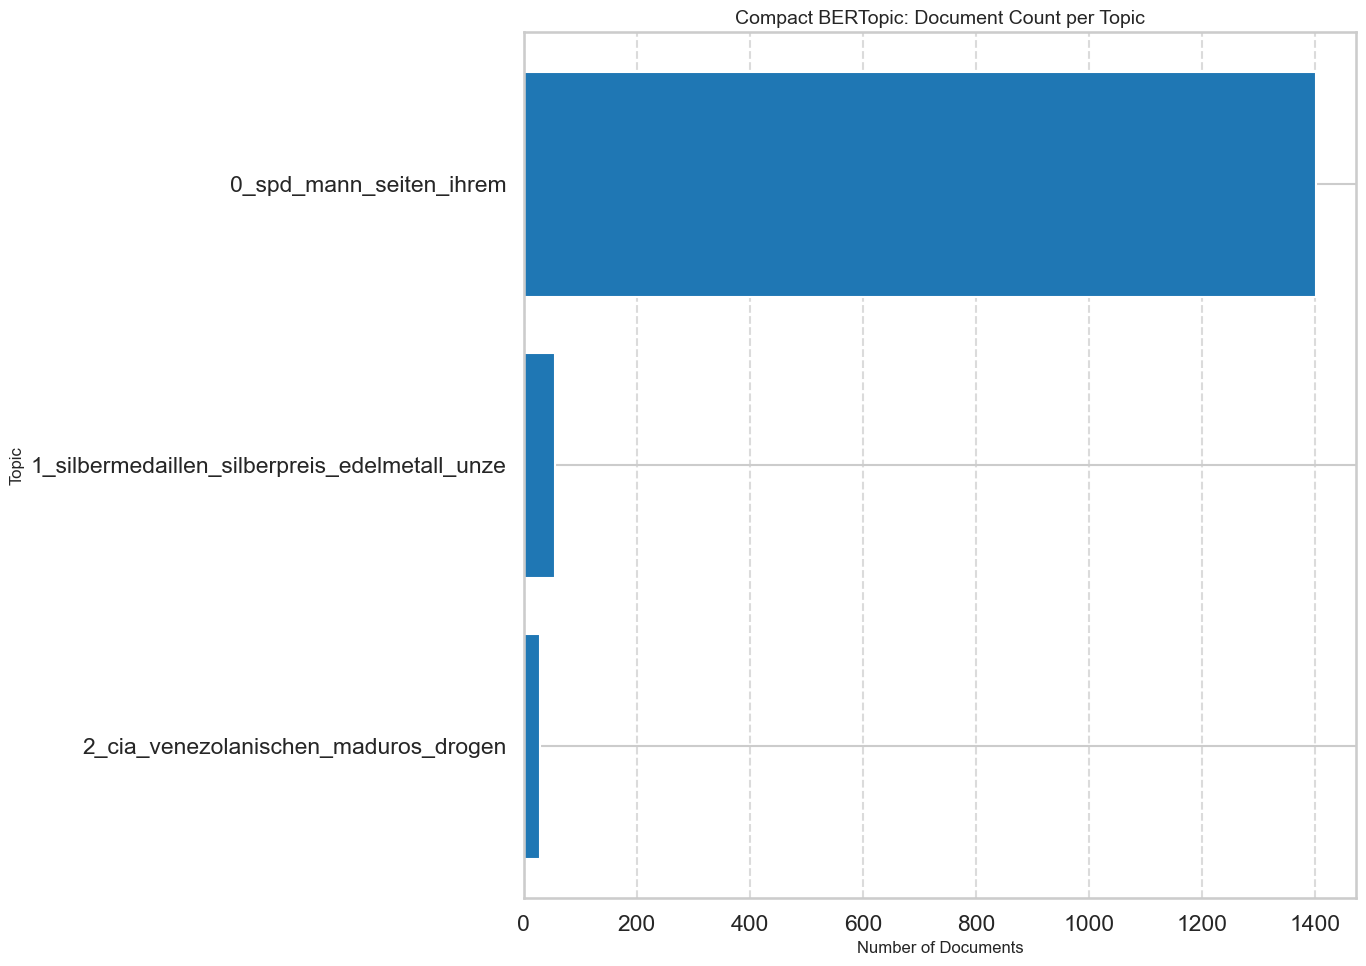

In [22]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Compact BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:02,  2.78it/s]


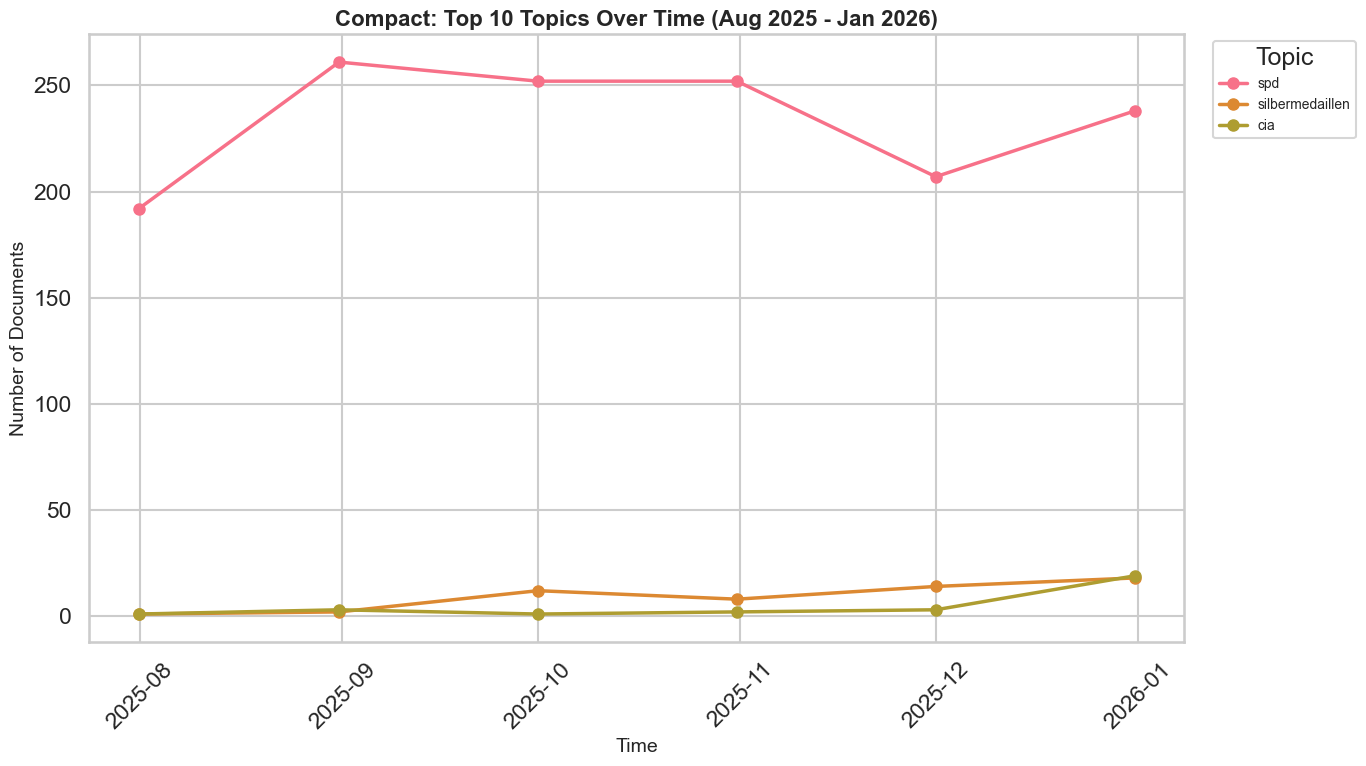

In [23]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Compact: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


,Topic,Name,Count,Representative_Words
0,0,0_spd_mann_seiten_ihrem,1402,"spd, mann, seiten, ihrem, bürger, opfer, grünen, gewalt, corona, gegen russland, merkel, stimmen, bsw, treffen, junge, mainstream, stadt, linken, offen, sachsen, morde, wehrpflicht, 12, bundestag, behörden, szene, berliner, rechts, aller, ort"
1,1,1_silbermedaillen_silberpreis_edelmetall_unze,55,"silbermedaillen, silberpreis, edelmetall, unze, anleger, katharina, preis für, reserve, stieg, inflation, papierwährungen, federal reserve, federal, währungen, 20 januar, anstieg, zinsen, unzen, treibt, notenbank, freitag, bundesbank, physischem, putin höcke, goldreserven, feinunze, us notenbank, knapp, putin druschba, flüchten"
2,2,2_cia_venezolanischen_maduros_drogen,29,"cia, venezolanischen, maduros, drogen, venezolanische, daniele, chavez, operation, intervention, imperium, imperium usa, operationen, militärische, skrupellose, usa skrupellose, nicolás maduro, nicolás, küste venezuelas, skrupellose weltmacht, amerikanischer, weltmacht, 10 2025, heft, kokain, daniele gansers, gansers, karibik, gansers imperium, hintergründe, venezuela attackieren"


In [25]:
print("Experimental BERTopic v2 run removed. The saved final Compact model uses the standard BERTopic pipeline above.")


Experimental BERTopic v2 run removed. The saved final Compact model uses the standard BERTopic pipeline above.


In [ ]:
from pathlib import Path
import shutil
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_full_text).
base_result = result_full_text
topic_model_base = base_result["topic_model"]
docs_cm = list(base_result["docs"])
topics_cm = list(base_result["topics"])
baseline_topic_ids = {topic for topic in topics_cm if topic != -1}
has_outliers = -1 in topics_cm

if has_outliers:
    new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
        docs_cm,
        topics_cm,
        strategy="c-tf-idf",
        threshold=0.10,
    )
    new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)
else:
    print("No outliers found in the Compact baseline model; skipping reduce_outliers and saving the baseline model as final.")
    new_topics_ctfidf_threshold = list(topics_cm)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
if has_outliers:
    vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
    ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
    representation_same = deepcopy(topic_model_base.representation_model)

    topic_model_ctfidf_threshold.update_topics(
        docs_cm,
        topics=new_topics_ctfidf_threshold,
        vectorizer_model=vectorizer_same,
        ctfidf_model=ctfidf_same,
        representation_model=representation_same,
        top_n_words=topic_model_base.top_n_words,
    )
    topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

# Reduce to 25 topics — Compact (1,486 docs) is too small for 74 topics;
# 25 gives ~50 docs/topic on average, which is defensible for a thesis corpus.
NR_TOPICS_COMPACT = 25
topic_model_ctfidf_threshold.reduce_topics(docs_cm, nr_topics=NR_TOPICS_COMPACT)
new_topics_ctfidf_threshold = list(topic_model_ctfidf_threshold.topics_)
print(f"After reduce_topics({NR_TOPICS_COMPACT}): "
      f"{len(set(t for t in new_topics_ctfidf_threshold if t != -1))} topics, "
      f"{sum(1 for t in new_topics_ctfidf_threshold if t == -1)} outliers")

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row["DisplayTopic"])} — {row["TopicNameClean"]}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_compact_reduced = dict(base_result)
result_compact_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_compact_reduced["topic_model"] = topic_model_ctfidf_threshold
result_compact_reduced["topic_info"] = topic_info_ctfidf_threshold
result_compact_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_compact_reduced["doc_info"] = doc_info_reduced
result_compact_reduced["display_topic_map"] = display_topic_map
result_compact_reduced["display_label_map"] = display_label_map

# Keep a reusable reduced result dict in notebook memory and make it the current Compact result.
result = result_compact_reduced
topic_info = result["topic_info"]

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
save_dir = project_root / "1a_BERTopic" / "local_outputs" / "compact_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_cm) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": f"ctfidf_0.10 + reduce_topics({NR_TOPICS_COMPACT})",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(set(t for t in new_topics_ctfidf_threshold if t != -1)),
    },
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(30))
print(f"Saved final reduced Compact model to: {save_dir}")